In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

## COMPLETION ACTIVITY: Steady state variability

The elementary liquid phase reaction

$$A \longrightarrow B$$

is carried out in a non-isothermal CSTR. Species A and an inert I are fed to the reactor in equimolar amounts. The molar feed rate of A is 80 mol/min. The heat capacity of the inert is 30 cal/mol/K. The heat capacities of A and B are 20 cal/mol/K. Additionally:

$$\tau = 100 \ \mathrm{min}$$
$$\Delta H^{rxn} = -7500 \ \mathrm{cal/mol} $$
$$UA = 8000 \ \mathrm{cal/min/K}$$
$$T_a = 300 \ \mathrm{K}$$
$$k = 0.0066 \ \mathrm{min}^{-1} \ \mathrm{at} \ 350 \ \mathrm{K}$$
$$ E = 40 \ \mathrm{kcal/mol}$$
$$T_0 \ \mathrm{can\ be\ varied}$$

# Question 1

In class, we developed the following equations:

$$X_{MB} = \frac{\tau k}{1+\tau k}$$

$$X_{EB} = \frac{F_{A0}C_{P,A}\left(T_0-T\right)+F_{I0}C_{P,I}\left(T_0-T\right) + UA\left(T_a-T\right)}{\Delta H^{rxn} F_{A0}}$$

However, this activity asks for G(T) and R(T). These are simple conversions:

$$G(T) = X_{MB}\left(-\Delta H^{rxn}\right)$$
$$R(T) = X_{EB}\left(-\Delta H^{rxn}\right)$$

Hence, we can modify our function slightly:

In [ ]:
FA0 = 80
FI0 = FA0
CPA = 20
CPI = 30
tau = 100
dHrxn = -7500
UA = 8000
Ta = 300
kref = 0.0066
Tref = 350
T0 = 450
E = 4000
R_gas = 1.987

def k(T):
  return kref*np.exp((E/R_gas)*(1/Tref-1/T))

def G(T):
  return -dHrxn*tau*k(T)/(1 + tau*k(T))

def R(T):
  numerator = -dHrxn*(FA0*CPA*(T0-T) + FI0*CPI*(T0-T) + UA*(Ta-T))
  denominator = dHrxn*FA0
  return numerator/denominator

def objective(T):
  return G(T) - R(T)

# Question 2

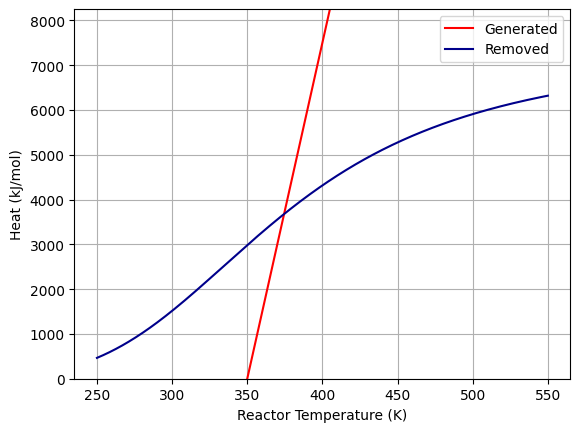

In [ ]:
T = np.linspace(250,550,500)

plt.plot(T, R(T), color="red", label="Generated")
plt.plot(T, G(T), color="darkblue", label="Removed")
plt.xlabel("Reactor Temperature (K)")
plt.ylabel("Heat (cal/mol)")
plt.legend()
plt.ylim(0, -dHrxn*1.1)
plt.grid()
plt.show()

## Question 3

Add your answer for question 3 here:

## Question 4

Add your answer for question 4 here:

## Question 5

Add your answer for question 5 here:

## Question 6

Vary T0 and replot:

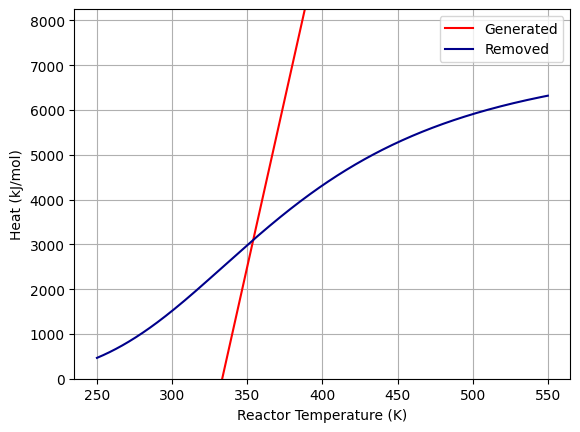

In [ ]:
T0 = 400
T = np.linspace(250,550,500)

plt.plot(T, R(T), color="red", label="Generated")
plt.plot(T, G(T), color="darkblue", label="Removed")
plt.xlabel("Reactor Temperature (K)")
plt.ylabel("Heat (cal/mol)")
plt.legend()
plt.ylim(0, -dHrxn*1.1)
plt.grid()
plt.show()

Describe what happened to R(T) when you varied T0:



Describe what happened to G(T) when you varied T0:



## Question 7

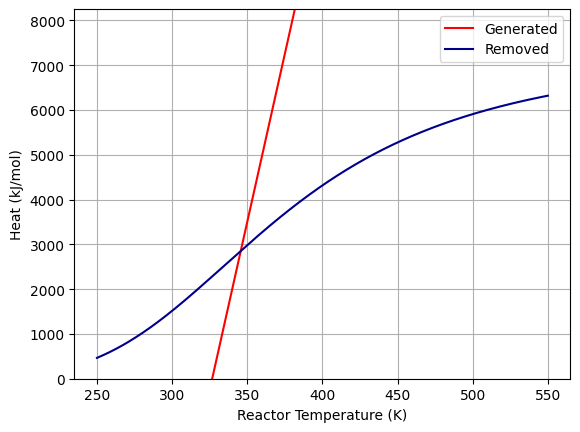

In [ ]:
T0 = 380
T = np.linspace(250,550,500)

plt.plot(T, R(T), color="red", label="Generated")
plt.plot(T, G(T), color="darkblue", label="Removed")
plt.xlabel("Reactor Temperature (K)")
plt.ylabel("Heat (cal/mol)")
plt.legend()
plt.ylim(0, -dHrxn*1.1)
plt.grid()
plt.show()

In [ ]:
Tguess = 340
T_solution = fsolve(objective, x0=Tguess)
print("Steady-state temperature for a guess of ",Tguess," = ", T_solution[0], " K")

Steady-state temperature for a guess of  340  =  345.69502500795915  K


Enter your explanation for question 7 here:

## Question 8

X = 0.8 means G(T) = R(T) = 6000 cal/mol, since

$$\frac{6000}{7500} = 0.8$$

Hence, write some code to identify where G(T) or R(T) = 6000 AND G(T) = R(T).

In [ ]:
# G(T) doesn't depend on T0. Hence, we can identify what reactor temperature gives G(T) = 6000:
X_target = 0.8
Heat_target = X_target*(-dHrxn)

T_target = fsolve(lambda T: G(T) - 6000, 450)[0]

# Rearranging R(T) formulation to solve for T0:
def calculate_T0(T):
    numerator =  -Heat_target * FA0 - UA * (Ta - T) + (FI0 * CPI + FA0 * CPA) * T
    denominator = FA0 * CPA + FI0 * CPI
    return numerator / denominator

T0_min = calculate_T0(T_target)

# Print results
print("T0_min = ", T0_min, " K")
print("Reactor temp = ",T_target," K")
T0 = T0_min
print("G(T) = ", G(T_target)," cal/mol")
print("R(T) = ", R(T_target), " cal/mol")

T0_min =  808.9788613776823  K
Reactor temp =  509.6596204592274  K
G(T) =  5999.999999999873  cal/mol
R(T) =  6000.0  cal/mol


Plot the results to ensure that they are reasonable:

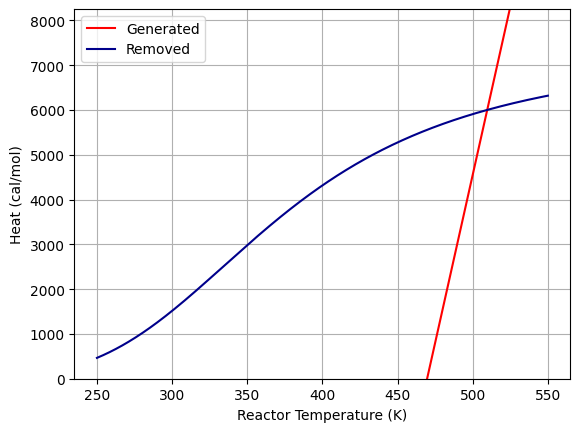

In [ ]:
T = np.linspace(250,550,500)

plt.plot(T, R(T), color="red", label="Generated")
plt.plot(T, G(T), color="darkblue", label="Removed")
plt.xlabel("Reactor Temperature (K)")
plt.ylabel("Heat (cal/mol)")
plt.legend()
plt.ylim(0, -dHrxn*1.1)
plt.grid()
plt.show()

Provide your answer for Question 8 here:

## Relevant CBE 3610 Reference Book Equations
- Eq. (21): CSTR Mole Balance
- Eq. (28): CSTR Energy Balance
- Eq. (29): κ Definition
- Eq. (30): Tc Definition
- Eq. (31): Simplified CSTR Energy Balance
- Eq. (44): General Rate Law
- Eq. (45): Power Law Kinetics
- Eq. (49): Arrhenius Equation